# DAS 507 — Lecture 2. 선형대수 (Linear Algebra) 보조실습

**고려대학교 통계학과 | 데이터과학을 위한 수리적 기초**

이 노트북은 선형대수의 핵심 개념을 NumPy를 활용하여 실습하는 자료입니다.

### 목차
1. **기본 설정 및 라이브러리 임포트**
2. **벡터의 기본 개념과 연산**
3. **내적, 직교, 코사인 유사도, 유클리드 거리**
4. **행렬의 기본 연산**
5. **행렬 곱셈의 성질 (교환법칙·분배법칙·전치)**
6. **열벡터의 선형조합**
7. **양의 정부호 행렬**
8. **대각합 (Trace)**
9. **넘파이 브로드캐스팅과 축(Axis)**
10. **선형 연립방정식과 역행렬**
11. **선형 독립/종속과 행렬의 계수(Rank)**
12. **행렬식 (Determinant)**
13. **고윳값과 고유벡터**
14. **고유분해 (대각화)**
15. **종합 연습문제**


## 1. 기본 설정 및 라이브러리 임포트

In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

# 출력 소수점 자리 설정
np.set_printoptions(precision=6, suppress=True)

print("NumPy 버전:", np.__version__)
print("준비 완료!")

NumPy 버전: 2.4.2
준비 완료!


In [2]:
import matplotlib.font_manager as fm
import matplotlib as mpl
# 설치된 폰트 중 "NanumGothic" 경로를 찾아 등록
font_path = None
for f in fm.findSystemFonts():
    if "NanumGothic" in f:
        font_path = f
        break

if font_path is None:
    raise RuntimeError("NanumGothic 폰트를 못 찾았어요. fonts-nanum 설치부터 확인하세요.")

fm.fontManager.addfont(font_path)
nanum_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = nanum_name
mpl.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

print("✅ Matplotlib 한글 폰트:", nanum_name)

✅ Matplotlib 한글 폰트: NanumGothicCoding


## 2. 벡터의 기본 개념과 연산

### 2.1 벡터 생성
벡터는 크기와 방향을 동시에 가지는 양입니다. NumPy에서는 `np.array`로 생성합니다.


In [3]:
# 다양한 방법으로 벡터 생성
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("벡터 a:", a)
print("벡터 b:", b)
print("a의 shape:", a.shape)
print("a의 차원:", a.ndim)

벡터 a: [1 2 3]
벡터 b: [4 5 6]
a의 shape: (3,)
a의 차원: 1


### 2.2 벡터의 길이 (Norm)

$$\|\mathbf{a}\| = \sqrt{a_1^2 + a_2^2 + \cdots + a_n^2}$$


In [4]:
# 벡터의 길이(노름) 계산
a = np.array([1, 2])
print("벡터 a:", a)
print("벡터의 길이 (np.linalg.norm):", LA.norm(a))
print("수동 계산:", np.sqrt(np.sum(a**2)))

# 3차원 벡터
v = np.array([3, 4, 0])
print("벡터 v:", v)
print("벡터 v의 길이:", LA.norm(v))

벡터 a: [1 2]
벡터의 길이 (np.linalg.norm): 2.23606797749979
수동 계산: 2.23606797749979
벡터 v: [3 4 0]
벡터 v의 길이: 5.0


### 2.3 벡터의 덧셈과 뺄셈

$$\mathbf{a} \pm \mathbf{b} = (a_1 \pm b_1,\; a_2 \pm b_2,\; \ldots,\; a_n \pm b_n)$$


In [5]:
x = np.array([10, 11, 12])
y = np.array([0, 1, 2])

print("x =", x)
print("y =", y)
print("x + y =", x + y)
print("x - y =", x - y)

x = [10 11 12]
y = [0 1 2]
x + y = [10 12 14]
x - y = [10 10 10]


### 2.4 스칼라와 벡터의 곱셈

$$k\mathbf{a} = (ka_1,\; ka_2,\; \ldots,\; ka_n)$$

양의 스칼라를 곱하면 방향은 유지, 음의 스칼라를 곱하면 방향이 반대됩니다.


a  = [1 2]
2a = [2 4]
-2a = [-2 -4]


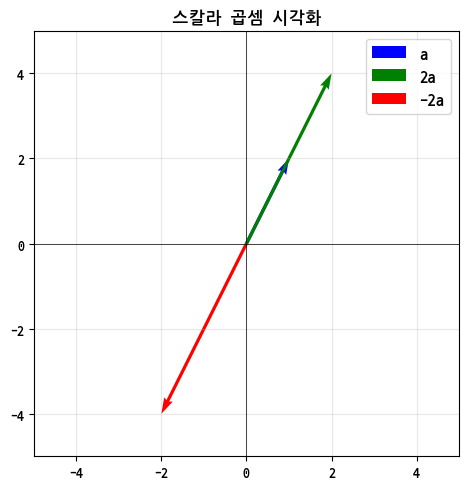

In [6]:
a = np.array([1, 2])
b = 2 * a
c = -2 * a

print("a  =", a)
print("2a =", b)
print("-2a =", c)

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
origin = np.array([0, 0])
for vec, label, color in [(a, 'a', 'blue'), (b, '2a', 'green'), (c, '-2a', 'red')]:
    ax.quiver(*origin, *vec, angles='xy', scale_units='xy', scale=1, color=color, label=label)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_title('스칼라 곱셈 시각화')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

### 2.5 단위벡터 (Unit Vector)

길이가 1인 벡터. 임의의 영벡터가 아닌 벡터 $\mathbf{x}$에 대해:

$$\hat{\mathbf{x}} = \frac{\mathbf{x}}{\|\mathbf{x}\|}$$


In [7]:
# 단위벡터 예시
e1 = np.array([1, 0])
e2 = np.array([0, 1])
c = np.array([1/np.sqrt(2), 1/np.sqrt(2)])

print("e1의 길이:", LA.norm(e1))
print("e2의 길이:", LA.norm(e2))
print("c의 길이:", LA.norm(c))

# 임의의 벡터를 단위벡터로 변환
x = np.array([3, 4])
x_unit = x / LA.norm(x)
print("벡터 x:", x, "길이:", LA.norm(x))
print("단위벡터:", x_unit, "길이:", LA.norm(x_unit))

e1의 길이: 1.0
e2의 길이: 1.0
c의 길이: 0.9999999999999999
벡터 x: [3 4] 길이: 5.0
단위벡터: [0.6 0.8] 길이: 1.0


### 2.6 선형조합 (Linear Combination)

$$c_1\mathbf{x}_1 + c_2\mathbf{x}_2 + \cdots + c_N\mathbf{x}_N$$


2*x1 + 3*x2 + -1*x3 = [ 2  3 -1]


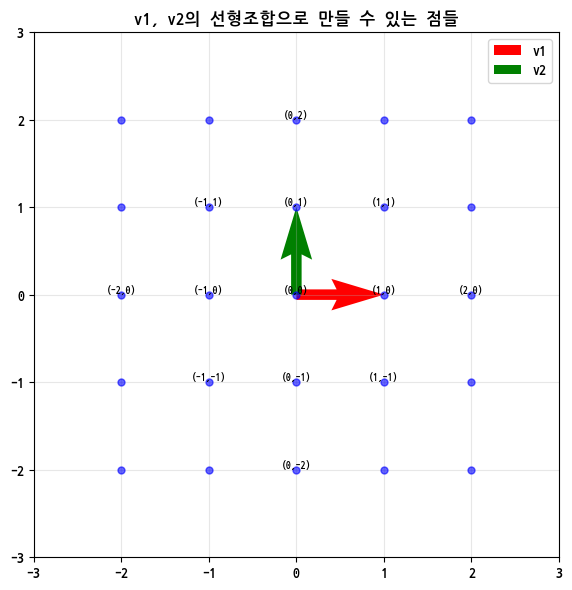

In [8]:
# 선형조합 예제
x1 = np.array([1, 0, 0])
x2 = np.array([0, 1, 0])
x3 = np.array([0, 0, 1])

c1, c2, c3 = 2, 3, -1

result = c1 * x1 + c2 * x2 + c3 * x3
print(f"{c1}*x1 + {c2}*x2 + {c3}*x3 = {result}")

# 2차원 시각화
v1 = np.array([1, 0])
v2 = np.array([0, 1])

fig, ax = plt.subplots(figsize=(6, 6))
# 여러 선형조합 시각화
for c1_val in np.arange(-2, 3):
    for c2_val in np.arange(-2, 3):
        point = c1_val * v1 + c2_val * v2
        ax.plot(*point, 'bo', markersize=5, alpha=0.6)
        if abs(c1_val) + abs(c2_val) <= 2:
            ax.annotate(f'({c1_val:.0f},{c2_val:.0f})', point, fontsize=7, ha='center', va='bottom')

ax.quiver(0, 0, *v1, angles='xy', scale_units='xy', scale=1, color='red', label='v1', width=0.02)
ax.quiver(0, 0, *v2, angles='xy', scale_units='xy', scale=1, color='green', label='v2', width=0.02)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title('v1, v2의 선형조합으로 만들 수 있는 점들')
plt.tight_layout()
plt.show()

## 3. 내적, 직교, 코사인 유사도, 유클리드 거리

### 3.1 벡터의 내적 (Inner Product / Dot Product)

$$\mathbf{x}^T\mathbf{y} = \sum_{i=1}^{n} x_i y_i$$

기하학적 의미: $\mathbf{a}^T\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$


In [9]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# 내적 계산 (여러 가지 방법)
dot1 = np.dot(x, y)
dot2 = x @ y
dot3 = np.sum(x * y)

print("x =", x)
print("y =", y)
print("np.dot(x, y) =", dot1)
print("x @ y        =", dot2)
print("np.sum(x*y)  =", dot3)
print("수동 계산: 1*4 + 2*5 + 3*6 =", 1*4 + 2*5 + 3*6)

x = [1 2 3]
y = [4 5 6]
np.dot(x, y) = 32
x @ y        = 32
np.sum(x*y)  = 32
수동 계산: 1*4 + 2*5 + 3*6 = 32


### 3.2 가중합 (Weighted Sum)

In [10]:
# 가중합 예제: 포트폴리오 수익률
weights = np.array([0.3, 0.5, 0.2])  # 가중치
returns = np.array([0.05, 0.08, 0.12])  # 각 자산 수익률

portfolio_return = weights @ returns
print("가중치:", weights)
print("수익률:", returns)
print(f"포트폴리오 수익률: {portfolio_return:.4f} ({portfolio_return*100:.2f}%)")

가중치: [0.3 0.5 0.2]
수익률: [0.05 0.08 0.12]
포트폴리오 수익률: 0.0790 (7.90%)


### 3.3 직교 (Orthogonal)

두 벡터 $\mathbf{a}$와 $\mathbf{b}$가 이루는 각이 90°이면 서로 직교. $\mathbf{a}^T\mathbf{b} = 0$


a = [1 1]
b = [-1  1]
a·b = 0
직교 여부: True


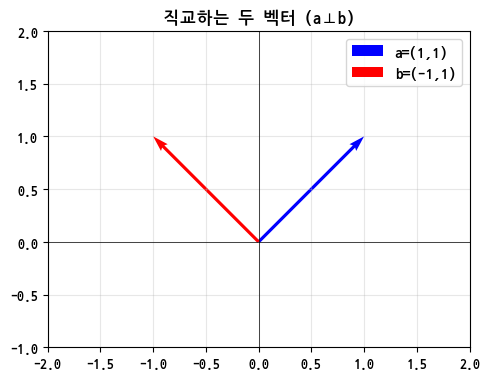

In [11]:
a = np.array([1, 1])
b = np.array([-1, 1])

print("a =", a)
print("b =", b)
print("a·b =", np.dot(a, b))
print("직교 여부:", np.dot(a, b) == 0)

# 시각화
fig, ax = plt.subplots(figsize=(5, 5))
origin = [0, 0]
ax.quiver(*origin, *a, angles='xy', scale_units='xy', scale=1, color='blue', label='a=(1,1)')
ax.quiver(*origin, *b, angles='xy', scale_units='xy', scale=1, color='red', label='b=(-1,1)')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_title('직교하는 두 벡터 (a⊥b)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

### 3.4 정규직교 (Orthonormal)

$N$개의 단위벡터 $\mathbf{v}_1, \ldots, \mathbf{v}_N$이 서로 직교하면 **정규직교**:
- $\mathbf{v}_i^T\mathbf{v}_i = 1$ (단위벡터)
- $\mathbf{v}_i^T\mathbf{v}_j = 0 \;(i \neq j)$ (직교)


In [12]:
# 정규직교 벡터 확인
v1 = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
v2 = np.array([-1/np.sqrt(2), 1/np.sqrt(2)])

print("v1 =", v1)
print("v2 =", v2)
print("||v1|| =", LA.norm(v1))
print("||v2|| =", LA.norm(v2))
print("v1·v2 =", np.dot(v1, v2))
print("정규직교:", np.isclose(LA.norm(v1), 1) and np.isclose(LA.norm(v2), 1) and np.isclose(np.dot(v1, v2), 0))

v1 = [0.707107 0.707107]
v2 = [-0.707107  0.707107]
||v1|| = 0.9999999999999999
||v2|| = 0.9999999999999999
v1·v2 = 2.2371143170757382e-17
정규직교: True


### 3.5 코사인 유사도 (Cosine Similarity)

$$\cos\theta = \frac{\mathbf{x}^T\mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$$

코사인 거리 $= 1 - \cos\theta$


In [13]:
def cosine_similarity(x, y):
    return np.dot(x, y) / (LA.norm(x) * LA.norm(y))

def cosine_distance(x, y):
    return 1 - cosine_similarity(x, y)

# 예제: 영화 평점 벡터
a = np.array([4, 5, 2, 2])  # 사용자 a
b = np.array([4, 0, 2, 0])  # 사용자 b
c = np.array([2, 2, 0, 1])  # 사용자 c

print("=== 코사인 유사도 ===")
print(f"cos(a, b) = {cosine_similarity(a, b):.6f}")
print(f"cos(a, c) = {cosine_similarity(a, c):.6f}")
print(f"cos(b, c) = {cosine_similarity(b, c):.6f}")

print("=== 코사인 거리 ===")
print(f"d_cos(a, b) = {cosine_distance(a, b):.6f}")
print(f"d_cos(a, c) = {cosine_distance(a, c):.6f}")
print(f"d_cos(b, c) = {cosine_distance(b, c):.6f}")

# 가장 가까운/먼 쌍 판별
distances = {
    '(a,b)': cosine_distance(a, b),
    '(a,c)': cosine_distance(a, c),
    '(b,c)': cosine_distance(b, c)
}
print(f"코사인 거리 기준 가장 가까운 쌍: {min(distances, key=distances.get)}")
print(f"코사인 거리 기준 가장 먼 쌍: {max(distances, key=distances.get)}")

=== 코사인 유사도 ===
cos(a, b) = 0.638877
cos(a, c) = 0.952381
cos(b, c) = 0.596285
=== 코사인 거리 ===
d_cos(a, b) = 0.361123
d_cos(a, c) = 0.047619
d_cos(b, c) = 0.403715
코사인 거리 기준 가장 가까운 쌍: (a,c)
코사인 거리 기준 가장 먼 쌍: (b,c)


### 3.6 유클리드 거리 (Euclidean Distance)

$$\|\mathbf{a} - \mathbf{b}\| = \sqrt{\sum_i (a_i - b_i)^2}$$


In [14]:
def euclidean_distance(x, y):
    return LA.norm(x - y)

# 같은 영화 평점 예제
print("=== 유클리드 거리 ===")
print(f"d(a, b) = {euclidean_distance(a, b):.6f}")
print(f"d(a, c) = {euclidean_distance(a, c):.6f}")
print(f"d(b, c) = {euclidean_distance(b, c):.6f}")

eu_distances = {
    '(a,b)': euclidean_distance(a, b),
    '(a,c)': euclidean_distance(a, c),
    '(b,c)': euclidean_distance(b, c)
}
print(f"유클리드 거리 기준 가장 가까운 쌍: {min(eu_distances, key=eu_distances.get)}")
print(f"유클리드 거리 기준 가장 먼 쌍: {max(eu_distances, key=eu_distances.get)}")

=== 유클리드 거리 ===
d(a, b) = 5.385165
d(a, c) = 4.242641
d(b, c) = 3.605551
유클리드 거리 기준 가장 가까운 쌍: (b,c)
유클리드 거리 기준 가장 먼 쌍: (a,b)


### 3.7 내적의 기하학적 의미 — 사영 (Projection)

벡터 $\mathbf{a}$를 $\mathbf{b}$ 방향으로 사영한 길이:

$$\|\mathbf{a}\|\cos\theta = \frac{\mathbf{a}^T\mathbf{b}}{\|\mathbf{b}\|}$$


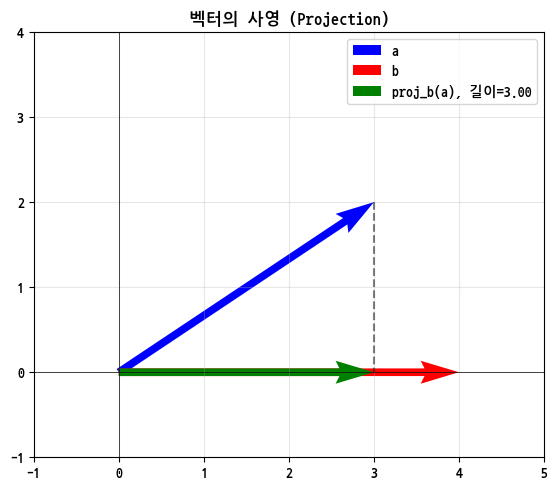

사영 길이: 3.0000
사영 벡터: [3. 0.]


In [15]:
# 사영(projection) 시각화
a = np.array([3, 2])
b = np.array([4, 0])

# a를 b 방향으로 사영
proj_length = np.dot(a, b) / LA.norm(b)
b_unit = b / LA.norm(b)
proj_vector = proj_length * b_unit

fig, ax = plt.subplots(figsize=(7, 5))
ax.quiver(0, 0, *a, angles='xy', scale_units='xy', scale=1, color='blue', label='a', width=0.015)
ax.quiver(0, 0, *b, angles='xy', scale_units='xy', scale=1, color='red', label='b', width=0.015)
ax.quiver(0, 0, *proj_vector, angles='xy', scale_units='xy', scale=1, color='green',
          label=f'proj_b(a), 길이={proj_length:.2f}', width=0.015)
# 수선
ax.plot([a[0], proj_vector[0]], [a[1], proj_vector[1]], 'k--', alpha=0.5)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_title('벡터의 사영 (Projection)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"사영 길이: {proj_length:.4f}")
print(f"사영 벡터: {proj_vector}")

### ✏️ 연습문제 1

**문제 1**: 직교하는 두 $N$차원 벡터 $\mathbf{a}, \mathbf{b}$에 대해 $\|\mathbf{a}+\mathbf{b}\|^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2$ 성립 확인


In [16]:
# 연습문제 1-1: 피타고라스 정리 (직교벡터)
a = np.array([1, 1, 0, 0])
b = np.array([0, 0, 1, -1])

print("a·b =", np.dot(a, b), "(직교 확인)")
print()
lhs = LA.norm(a + b)**2
rhs = LA.norm(a)**2 + LA.norm(b)**2
print(f"||a+b||² = {lhs:.6f}")
print(f"||a||² + ||b||² = {rhs:.6f}")
print(f"같은가? {np.isclose(lhs, rhs)}")

# 증명: ||a+b||² = (a+b)ᵀ(a+b) = aᵀa + 2aᵀb + bᵀb = ||a||² + 0 + ||b||²
print("[증명]")
print("||a+b||² = (a+b)ᵀ(a+b) = aᵀa + 2·aᵀb + bᵀb")
print(f"         = {LA.norm(a)**2} + 2×{np.dot(a,b)} + {LA.norm(b)**2}")
print(f"         = {LA.norm(a)**2 + LA.norm(b)**2}")

a·b = 0 (직교 확인)

||a+b||² = 4.000000
||a||² + ||b||² = 4.000000
같은가? True
[증명]
||a+b||² = (a+b)ᵀ(a+b) = aᵀa + 2·aᵀb + bᵀb
         = 2.0000000000000004 + 2×0 + 2.0000000000000004
         = 4.000000000000001


**문제 2**: 영화 평점 벡터의 유클리드 거리와 코사인 거리 비교 (위 3.5, 3.6에서 이미 풀었습니다)

## 4. 행렬의 기본 연산

### 4.1 행렬 생성 및 기본 연산


In [17]:
# 행렬 생성
X = np.array([[1, 2, 3],
              [4, 5, 6]])

Y = np.array([[7, 8, 9],
              [10, 11, 12]])

print("X =")
print(X)
print(f"shape: {X.shape} (n×p = {X.shape[0]}×{X.shape[1]})")

print("Y =")
print(Y)

X =
[[1 2 3]
 [4 5 6]]
shape: (2, 3) (n×p = 2×3)
Y =
[[ 7  8  9]
 [10 11 12]]


In [18]:
# 행렬 덧셈과 뺄셈
print("X + Y =")
print(X + Y)

print("X - Y =")
print(X - Y)

X + Y =
[[ 8 10 12]
 [14 16 18]]
X - Y =
[[-6 -6 -6]
 [-6 -6 -6]]


In [19]:
# 행렬과 스칼라의 곱셈
print("3X =")
print(3 * X)

3X =
[[ 3  6  9]
 [12 15 18]]


### 4.2 행렬과 벡터의 곱셈

In [20]:
# 행렬 × 벡터 (오른쪽에서 곱)
X = np.array([[1, 2, 3],
              [4, 5, 6]])
k = np.array([1, 2, 3])

print("X =")
print(X)
print("k =", k)
print("Xk =", X @ k)  # (2×3) @ (3,) = (2,)
print("수동: [1*1+2*2+3*3, 4*1+5*2+6*3] =", [1+4+9, 4+10+18])

X =
[[1 2 3]
 [4 5 6]]
k = [1 2 3]
Xk = [14 32]
수동: [1*1+2*2+3*3, 4*1+5*2+6*3] = [14, 32]


In [21]:
# 벡터 × 행렬 (왼쪽에서 곱)
m = np.array([1, 2])
print("m =", m)
print("mX =", m @ X)  # (2,) @ (2×3) = (3,)

m = [1 2]
mX = [ 9 12 15]


### 4.3 행렬의 곱셈

In [22]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

B = np.array([[1, 2],
              [3, 4],
              [5, 6]])

print("A (2×3) =")
print(A)
print("B (3×2) =")
print(B)

# 행렬 곱셈
C = A @ B  # (2×3) @ (3×2) = (2×2)
print("AB (2×2) =")
print(C)

# np.dot으로도 가능
C2 = np.dot(A, B)
print("np.dot(A,B) =")
print(C2)

A (2×3) =
[[1 2 3]
 [4 5 6]]
B (3×2) =
[[1 2]
 [3 4]
 [5 6]]
AB (2×2) =
[[22 28]
 [49 64]]
np.dot(A,B) =
[[22 28]
 [49 64]]


In [23]:
# 행 벡터와 열 벡터 추출 후 곱셈
a1 = A[0, :]  # A의 첫 번째 행
b1 = B[:, 0]  # B의 첫 번째 열

print("a1 (A의 1행):", a1)
print("b1 (B의 1열):", b1)
print("a1 @ B =", a1 @ B)
print("A @ b1 =", A @ b1)

a1 (A의 1행): [1 2 3]
b1 (B의 1열): [1 3 5]
a1 @ B = [22 28]
A @ b1 = [22 49]


### 4.4 전치 행렬 (Transpose)

$$A^T_{ij} = A_{ji}$$


In [24]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

print("A =")
print(A)
print("Aᵀ =")
print(A.T)
print(f"A shape: {A.shape}, Aᵀ shape: {A.T.shape}")

A =
[[1 2 3]
 [4 5 6]]
Aᵀ =
[[1 4]
 [2 5]
 [3 6]]
A shape: (2, 3), Aᵀ shape: (3, 2)


## 5. 행렬 곱셈의 성질

### 5.1 교환법칙 (성립하지 않음!)

$$AB \neq BA$$


In [25]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
C = np.array([[9, 8], [7, 6]])

print("A =", A.tolist())
print("B =", B.tolist())
print("C =", C.tolist())

print("=== 교환법칙 검증 ===")
print("AB =")
print(A @ B)
print("BA =")
print(B @ A)
print("AB == BA?", np.array_equal(A @ B, B @ A))

A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
C = [[9, 8], [7, 6]]
=== 교환법칙 검증 ===
AB =
[[19 22]
 [43 50]]
BA =
[[23 34]
 [31 46]]
AB == BA? False


### 5.2 분배법칙 (성립!)

In [26]:
# A(B + C) = AB + AC
lhs = A @ (B + C)
rhs = A @ B + A @ C
print("A(B+C) =")
print(lhs)
print("AB + AC =")
print(rhs)
print("A(B+C) == AB+AC?", np.array_equal(lhs, rhs))

# (A + B)C = AC + BC
lhs2 = (A + B) @ C
rhs2 = A @ C + B @ C
print("(A+B)C =")
print(lhs2)
print("AC + BC =")
print(rhs2)
print("(A+B)C == AC+BC?", np.array_equal(lhs2, rhs2))

A(B+C) =
[[42 42]
 [98 98]]
AB + AC =
[[42 42]
 [98 98]]
A(B+C) == AB+AC? True
(A+B)C =
[[110  96]
 [174 152]]
AC + BC =
[[110  96]
 [174 152]]
(A+B)C == AC+BC? True


### 5.3 전치의 분배법칙

- $(A+B)^T = A^T + B^T$
- $(AB)^T = B^T A^T$ ← 순서 뒤집힘!


In [27]:
# (A+B)ᵀ = Aᵀ + Bᵀ
print("(A+B)ᵀ =")
print((A + B).T)
print("Aᵀ + Bᵀ =")
print(A.T + B.T)
print("같은가?", np.array_equal((A+B).T, A.T + B.T))

print("" + "="*40)

# (AB)ᵀ = BᵀAᵀ
print("(AB)ᵀ =")
print((A @ B).T)
print("BᵀAᵀ =")
print(B.T @ A.T)
print("같은가?", np.array_equal((A @ B).T, B.T @ A.T))

# 주의: AᵀBᵀ ≠ (AB)ᵀ
print("AᵀBᵀ =")
print(A.T @ B.T)
print("AᵀBᵀ == (AB)ᵀ?", np.array_equal(A.T @ B.T, (A @ B).T))

(A+B)ᵀ =
[[ 6 10]
 [ 8 12]]
Aᵀ + Bᵀ =
[[ 6 10]
 [ 8 12]]
같은가? True
(AB)ᵀ =
[[19 43]
 [22 50]]
BᵀAᵀ =
[[19 43]
 [22 50]]
같은가? True
AᵀBᵀ =
[[23 31]
 [34 46]]
AᵀBᵀ == (AB)ᵀ? False


## 6. 열벡터의 선형조합

행렬 $X$와 벡터 $\mathbf{w}$의 곱은 $X$의 열벡터들의 선형조합:

$$X\mathbf{w} = w_1\mathbf{x}_1 + w_2\mathbf{x}_2 + \cdots + w_p\mathbf{x}_p$$


In [28]:
X = np.array([[1, 2, 3],
              [4, 5, 6]])
w = np.array([2, 3, 4])

# 방법 1: 행렬-벡터 곱
result1 = X @ w

# 방법 2: 열벡터의 선형조합
x1 = X[:, 0]  # 첫 번째 열
x2 = X[:, 1]  # 두 번째 열
x3 = X[:, 2]  # 세 번째 열
result2 = w[0]*x1 + w[1]*x2 + w[2]*x3

print("X =")
print(X)
print("w =", w)
print("Xw (행렬곱) =", result1)
print("w1*x1 + w2*x2 + w3*x3 =", result2)
print("같은가?", np.array_equal(result1, result2))

X =
[[1 2 3]
 [4 5 6]]
w = [2 3 4]
Xw (행렬곱) = [20 47]
w1*x1 + w2*x2 + w3*x3 = [20 47]
같은가? True


In [29]:
# 고유분해 미리보기: Vλ = λ₁v₁ (λ의 나머지가 0인 경우)
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([0, 0, 1])

V = np.column_stack([v1, v2, v3])
lam = np.array([3, 0, 0])

print("V =")
print(V)
print("λ =", lam)
print("Vλ =", V @ lam)
print("λ₁v₁ =", lam[0] * v1)
print("같은가?", np.array_equal(V @ lam, lam[0] * v1))

V =
[[1 0 0]
 [0 1 0]
 [0 0 1]]
λ = [3 0 0]
Vλ = [3 0 0]
λ₁v₁ = [3 0 0]
같은가? True


## 7. 양의 정부호 행렬 (Positive Definite)

영벡터가 아닌 모든 벡터 $\mathbf{x}$에 대해 $\mathbf{x}^T A \mathbf{x} > 0$이면 **양의 정부호**.


In [30]:
# 항등행렬은 양의 정부호
I = np.eye(3)
x = np.array([1, -2, 3])

quad_form = x @ I @ x
print("I =")
print(I)
print("x =", x)
print("xᵀIx =", quad_form)
print("= x₁² + x₂² + x₃² =", np.sum(x**2))
print("> 0?", quad_form > 0)

I =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
x = [ 1 -2  3]
xᵀIx = 14.0
= x₁² + x₂² + x₃² = 14
> 0? True


In [31]:
# 연습문제 2: [[1,1],[1,1]]이 양의 정부호인지 판별
A = np.array([[1, 1], [1, 1]])
print("A =")
print(A)

# 여러 벡터로 테스트
test_vectors = [
    np.array([1, 0]),
    np.array([0, 1]),
    np.array([1, 1]),
    np.array([1, -1]),
    np.array([2, -2]),
]

print("이차형식 xᵀAx 값 확인:")
for v in test_vectors:
    val = v @ A @ v
    print(f"  x={v}, xᵀAx = {val}")

print("x=[1,-1]일 때 xᵀAx=0 이므로 양의 정부호가 아님.")
print("하지만 xᵀAx ≥ 0이므로 양의 '준'정부호(positive semi-definite).")

# 고윳값으로도 확인
eigvals = LA.eigvalsh(A)
print(f"고윳값: {eigvals}")
print("모두 ≥ 0? →", np.all(eigvals >= 0), "→ 양의 준정부호")
print("모두 > 0?  →", np.all(eigvals > 0), "→ 양의 정부호 아님")

A =
[[1 1]
 [1 1]]
이차형식 xᵀAx 값 확인:
  x=[1 0], xᵀAx = 1
  x=[0 1], xᵀAx = 1
  x=[1 1], xᵀAx = 4
  x=[ 1 -1], xᵀAx = 0
  x=[ 2 -2], xᵀAx = 0
x=[1,-1]일 때 xᵀAx=0 이므로 양의 정부호가 아님.
하지만 xᵀAx ≥ 0이므로 양의 '준'정부호(positive semi-definite).
고윳값: [0. 2.]
모두 ≥ 0? → True → 양의 준정부호
모두 > 0?  → False → 양의 정부호 아님


## 8. 대각합 (Trace)

$$\text{tr}(A) = \sum_{i=1}^N a_{ii}$$

### 성질
- $\text{tr}(cA) = c \cdot \text{tr}(A)$
- $\text{tr}(A^T) = \text{tr}(A)$
- $\text{tr}(A+B) = \text{tr}(A) + \text{tr}(B)$
- $\text{tr}(AB) = \text{tr}(BA)$
- $\text{tr}(ABC) = \text{tr}(BCA) = \text{tr}(CAB)$


In [32]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
C = np.array([[9, 8], [7, 6]])

print("A =", A.tolist())
print("tr(A) =", np.trace(A))

print("=== 대각합 성질 확인 ===")

# tr(cA) = c·tr(A)
c = 3
print(f"tr({c}A) = {np.trace(c*A)}, {c}·tr(A) = {c*np.trace(A)}")

# tr(Aᵀ) = tr(A)
print(f"tr(Aᵀ) = {np.trace(A.T)}, tr(A) = {np.trace(A)}")

# tr(A+B) = tr(A) + tr(B)
print(f"tr(A+B) = {np.trace(A+B)}, tr(A)+tr(B) = {np.trace(A)+np.trace(B)}")

# tr(AB) = tr(BA)
print(f"tr(AB) = {np.trace(A@B)}, tr(BA) = {np.trace(B@A)}")

# tr(ABC) = tr(BCA) = tr(CAB) (순환치환)
print(f"tr(ABC) = {np.trace(A@B@C)}")
print(f"tr(BCA) = {np.trace(B@C@A)}")
print(f"tr(CAB) = {np.trace(C@A@B)}")

# 항등행렬
print(f"tr(I₃) = {np.trace(np.eye(3))}")

A = [[1, 2], [3, 4]]
tr(A) = 5
=== 대각합 성질 확인 ===
tr(3A) = 15, 3·tr(A) = 15
tr(Aᵀ) = 5, tr(A) = 5
tr(A+B) = 18, tr(A)+tr(B) = 18
tr(AB) = 69, tr(BA) = 69
tr(ABC) = 969
tr(BCA) = 969
tr(CAB) = 969
tr(I₃) = 3.0


### ✏️ 연습문제 3: 이차형식과 대각합

In [33]:
# 연습문제 3-1: xᵀAx = tr(xᵀAx) = tr(AxxᵀT) = tr(xxᵀA)
x = np.array([[1], [2]])  # 열벡터 (2×1)
A = np.array([[3, 1], [1, 4]])

xTAx = (x.T @ A @ x)[0, 0]  # 스칼라

tr1 = np.trace(x.T @ A @ x)
tr2 = np.trace(A @ x @ x.T)
tr3 = np.trace(x @ x.T @ A)

print("x =", x.ravel())
print("A =", A.tolist())
print(f"xᵀAx     = {xTAx}")
print(f"tr(xᵀAx) = {tr1}")
print(f"tr(Axxᵀ) = {tr2}")
print(f"tr(xxᵀA) = {tr3}")
print("모두 같은가?", np.isclose(xTAx, tr1) and np.isclose(tr1, tr2) and np.isclose(tr2, tr3))

x = [1 2]
A = [[3, 1], [1, 4]]
xᵀAx     = 23
tr(xᵀAx) = 23
tr(Axxᵀ) = 23
tr(xxᵀA) = 23
모두 같은가? True


In [34]:
# 연습문제 3-2: ΣΣ a²ᵢⱼ = tr(AᵀA)
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

sum_sq = np.sum(A**2)
tr_AtA = np.trace(A.T @ A)

print("A =")
print(A)
print(f"ΣΣ a²ᵢⱼ   = {sum_sq}")
print(f"tr(AᵀA) = {tr_AtA}")
print(f"같은가? {np.isclose(sum_sq, tr_AtA)}")

A =
[[1 2 3]
 [4 5 6]
 [7 8 9]]
ΣΣ a²ᵢⱼ   = 285
tr(AᵀA) = 285
같은가? True


## 9. 넘파이 브로드캐스팅과 축 (Axis)

### 9.1 브로드캐스팅 (Broadcasting)

크기가 다른 배열 간의 연산 시 작은 배열이 자동으로 확장됩니다.


In [35]:
# 기본 브로드캐스팅: 배열 + 스칼라
a = np.array([1, 2, 3])
print("a + 10 =", a + 10)

# 같은 크기: 정상 작동
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("a + b =", a + b)

# 다른 크기: 에러
a = np.array([1, 2, 3])
b_bad = np.array([1, 2])
try:
    result = a + b_bad
except ValueError as e:
    print(f"에러 발생: {e}")

# 크기 1인 배열: 브로드캐스팅
b_ok = np.array([1])
print("a + [1] =", a + b_ok)

a + 10 = [11 12 13]
a + b = [5 7 9]
에러 발생: operands could not be broadcast together with shapes (3,) (2,) 
a + [1] = [2 3 4]


In [36]:
# 2D 행렬 + 1D 벡터 브로드캐스팅
A = np.arange(1, 13).reshape(4, 3)
b = np.array([1, 0, 1])

print("A (4×3) =")
print(A)
print("b (3,) =", b)
print("A + b (브로드캐스팅) =")
print(A + b)

A (4×3) =
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
b (3,) = [1 0 1]
A + b (브로드캐스팅) =
[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


In [37]:
# 열벡터(3,1) + 행벡터(1,3) → (3,3) 행렬
col = np.arange(3).reshape(3, 1)
row = np.arange(3).reshape(1, 3)

print("열벡터 (3,1):")
print(col)
print("행벡터 (1,3):")
print(row)
print("col + row (3,3):")
print(col + row)

열벡터 (3,1):
[[0]
 [1]
 [2]]
행벡터 (1,3):
[[0 1 2]]
col + row (3,3):
[[0 1 2]
 [1 2 3]
 [2 3 4]]


### 9.2 축 (Axis) 다루기

- `axis=0` → 행 방향 (아래쪽으로) 연산
- `axis=1` → 열 방향 (오른쪽으로) 연산


In [38]:
a = np.arange(6).reshape(2, 3)
print("a (2×3) =")
print(a)

print(f"np.sum(a)       = {np.sum(a)}")        # 전체 합
print(f"np.sum(a, axis=0) = {np.sum(a, axis=0)}")  # 열별 합 → shape (3,)
print(f"np.sum(a, axis=1) = {np.sum(a, axis=1)}")  # 행별 합 → shape (2,)

print(f"np.max(a, axis=0) = {np.max(a, axis=0)}")  # 열별 최대
print(f"np.max(a, axis=1) = {np.max(a, axis=1)}")  # 행별 최대

print(f"np.mean(a, axis=0) = {np.mean(a, axis=0)}")  # 열별 평균
print(f"np.mean(a, axis=1) = {np.mean(a, axis=1)}")  # 행별 평균

a (2×3) =
[[0 1 2]
 [3 4 5]]
np.sum(a)       = 15
np.sum(a, axis=0) = [3 5 7]
np.sum(a, axis=1) = [ 3 12]
np.max(a, axis=0) = [3 4 5]
np.max(a, axis=1) = [2 5]
np.mean(a, axis=0) = [1.5 2.5 3.5]
np.mean(a, axis=1) = [1. 4.]


In [39]:
# 3차원 배열의 축
a3d = np.arange(24).reshape(4, 2, 3)
print("3D 배열 shape:", a3d.shape)
print(a3d)

print(f"axis=0 합 shape: {np.sum(a3d, axis=0).shape}")
print(np.sum(a3d, axis=0))

print(f"axis=1 합 shape: {np.sum(a3d, axis=1).shape}")
print(np.sum(a3d, axis=1))

print(f"axis=2 합 shape: {np.sum(a3d, axis=2).shape}")
print(np.sum(a3d, axis=2))

3D 배열 shape: (4, 2, 3)
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]

 [[12 13 14]
  [15 16 17]]

 [[18 19 20]
  [21 22 23]]]
axis=0 합 shape: (2, 3)
[[36 40 44]
 [48 52 56]]
axis=1 합 shape: (4, 3)
[[ 3  5  7]
 [15 17 19]
 [27 29 31]
 [39 41 43]]
axis=2 합 shape: (4, 2)
[[ 3 12]
 [21 30]
 [39 48]
 [57 66]]


## 10. 선형 연립방정식과 역행렬

### 10.1 역행렬 (Inverse Matrix)

$$A^{-1}A = AA^{-1} = I$$


In [40]:
# 역행렬 계산
A = np.array([[1, 1, 0],
              [0, 1, 1],
              [1, 1, 1]])

print("A =")
print(A)

Ainv = LA.inv(A)
print("A⁻¹ =")
print(Ainv)

# 검증
print("A @ A⁻¹ =")
print(np.round(A @ Ainv, 10))

print("A⁻¹ @ A =")
print(np.round(Ainv @ A, 10))

A =
[[1 1 0]
 [0 1 1]
 [1 1 1]]
A⁻¹ =
[[ 0. -1.  1.]
 [ 1.  1. -1.]
 [-1.  0.  1.]]
A @ A⁻¹ =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
A⁻¹ @ A =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### 10.2 2×2 역행렬 공식

In [41]:
# 2×2 역행렬: A⁻¹ = 1/(ad-bc) * [[d,-b],[-c,a]]
A = np.array([[5, 6],
              [7, 8]])
a, b, c, d = A[0,0], A[0,1], A[1,0], A[1,1]

det = a*d - b*c
Ainv_manual = (1/det) * np.array([[d, -b], [-c, a]])

print("A =", A.tolist())
print(f"det(A) = {a}*{d} - {b}*{c} = {det}")
print("수동 역행렬:")
print(Ainv_manual)
print("np.linalg.inv(A):")
print(LA.inv(A))
print("같은가?", np.allclose(Ainv_manual, LA.inv(A)))

A = [[5, 6], [7, 8]]
det(A) = 5*8 - 6*7 = -2
수동 역행렬:
[[-4.   3. ]
 [ 3.5 -2.5]]
np.linalg.inv(A):
[[-4.   3. ]
 [ 3.5 -2.5]]
같은가? True


### 10.3 역행렬의 성질

- $(A^T)^{-1} = (A^{-1})^T$
- $(AB)^{-1} = B^{-1}A^{-1}$


In [42]:
A = np.array([[5, 6], [7, 8]])
B = np.array([[1, 2], [3, 4]])

Ainv = LA.inv(A)
Binv = LA.inv(B)

# (Aᵀ)⁻¹ = (A⁻¹)ᵀ
print("(Aᵀ)⁻¹ =")
print(LA.inv(A.T))
print("(A⁻¹)ᵀ =")
print(Ainv.T)
print("같은가?", np.allclose(LA.inv(A.T), Ainv.T))

# (AB)⁻¹ = B⁻¹A⁻¹
print("(AB)⁻¹ =")
print(LA.inv(A @ B))
print("B⁻¹A⁻¹ =")
print(Binv @ Ainv)
print("같은가?", np.allclose(LA.inv(A @ B), Binv @ Ainv))

(Aᵀ)⁻¹ =
[[-4.   3.5]
 [ 3.  -2.5]]
(A⁻¹)ᵀ =
[[-4.   3.5]
 [ 3.  -2.5]]
같은가? True
(AB)⁻¹ =
[[11.5  -8.5 ]
 [-7.75  5.75]]
B⁻¹A⁻¹ =
[[11.5  -8.5 ]
 [-7.75  5.75]]
같은가? True


### 10.4 선형 연립방정식 풀기

$$A\mathbf{x} = \mathbf{b} \quad\Rightarrow\quad \mathbf{x} = A^{-1}\mathbf{b}$$

또는 `np.linalg.solve(A, b)` 사용 (더 효율적!)


In [43]:
# 예: x₁ + x₂ = 2, x₂ + x₃ = 2, x₁ + x₂ + x₃ = 3
A = np.array([[1, 1, 0],
              [0, 1, 1],
              [1, 1, 1]])
b = np.array([2, 2, 3])

# 방법 1: 역행렬 이용
x1 = LA.inv(A) @ b

# 방법 2: np.linalg.solve (권장)
x2 = LA.solve(A, b)

print("A =")
print(A)
print("b =", b)
print("방법1 (A⁻¹b):", x1)
print("방법2 (solve):", x2)

# 검증
print("검증 Ax =", A @ x2)

A =
[[1 1 0]
 [0 1 1]
 [1 1 1]]
b = [2 2 3]
방법1 (A⁻¹b): [1. 1. 1.]
방법2 (solve): [1. 1. 1.]
검증 Ax = [2. 2. 3.]


In [44]:
# singular 행렬인 경우: 에러 발생
A_singular = np.array([[2, -5, 4],
                        [1, -2, 1],
                        [1, -3, 3]])
b = np.array([-3, 5, 10])

print("A =")
print(A_singular)
print(f"det(A) = {LA.det(A_singular):.10f}")
print(f"rank(A) = {LA.matrix_rank(A_singular)}")

try:
    x = LA.solve(A_singular, b)
    print("해:", x)
except LA.LinAlgError as e:
    print(f"에러 발생: {e}")
    print("→ 행렬이 특이(singular)이므로 유일한 해가 없습니다.")

A =
[[ 2 -5  4]
 [ 1 -2  1]
 [ 1 -3  3]]
det(A) = 0.0000000000
rank(A) = 2
에러 발생: Singular matrix
→ 행렬이 특이(singular)이므로 유일한 해가 없습니다.


## 11. 선형 독립/종속과 행렬의 계수 (Rank)

### 11.1 선형 독립 (Linearly Independent)

$c_1\mathbf{x}_1 + c_2\mathbf{x}_2 + \cdots + c_m\mathbf{x}_m = \mathbf{0}$ 에서 $c_1 = c_2 = \cdots = c_m = 0$만 가능하면 **선형 독립**.


In [45]:
# 선형독립 판별 함수
def check_independence(vectors, names=None):
    """벡터들의 선형 독립/종속 판별"""
    A = np.column_stack(vectors)
    r = LA.matrix_rank(A)
    n = len(vectors)
    independent = (r == n)

    if names is None:
        names = [f"v{i+1}" for i in range(n)]

    print(f"벡터: {', '.join(names)}")
    print(f"행렬 A =")
    print(A)
    print(f"rank(A) = {r}, 벡터 수 = {n}")
    print(f"→ {'선형 독립' if independent else '선형 종속'}")
    print()
    return independent

# 예제 1: 표준 기저벡터 → 독립
print("=" * 50)
print("예제 1: 표준기저벡터")
check_independence(
    [np.array([1,0,0]), np.array([0,1,0]), np.array([0,0,1])]
)

# 예제 2: 독립
print("=" * 50)
print("예제 2")
check_independence(
    [np.array([1,1,0]), np.array([1,0,1]), np.array([0,1,1])]
)

# 예제 3: 종속 (하나가 다른 것의 스칼라배)
print("=" * 50)
print("예제 3: (1,1,0)과 (2,2,0)은 평행")
check_independence(
    [np.array([1,1,0]), np.array([2,2,0])]
)

# 예제 4: 종속 (세 번째가 첫째 - 둘째)
print("=" * 50)
print("예제 4: (2,1,0) - (1,0,1) = (1,1,-1)")
check_independence(
    [np.array([2,1,0]), np.array([1,0,1]), np.array([1,1,-1])]
)

예제 1: 표준기저벡터
벡터: v1, v2, v3
행렬 A =
[[1 0 0]
 [0 1 0]
 [0 0 1]]
rank(A) = 3, 벡터 수 = 3
→ 선형 독립

예제 2
벡터: v1, v2, v3
행렬 A =
[[1 1 0]
 [1 0 1]
 [0 1 1]]
rank(A) = 3, 벡터 수 = 3
→ 선형 독립

예제 3: (1,1,0)과 (2,2,0)은 평행
벡터: v1, v2
행렬 A =
[[1 2]
 [1 2]
 [0 0]]
rank(A) = 1, 벡터 수 = 2
→ 선형 종속

예제 4: (2,1,0) - (1,0,1) = (1,1,-1)
벡터: v1, v2, v3
행렬 A =
[[ 2  1  1]
 [ 1  0  1]
 [ 0  1 -1]]
rank(A) = 2, 벡터 수 = 3
→ 선형 종속



np.False_

### 11.2 행렬의 계수 (Rank)

In [46]:
matrices = [
    ("I₃", np.eye(3)),
    ("A₂", np.array([[1,1,0],[1,0,1],[0,1,1]])),
    ("A₃", np.array([[2,1,1],[1,0,1],[1,1,0]])),
    ("A₄", np.array([[2,4,1],[1,2,0.5],[0.5,1,0.25]])),
]

for name, M in matrices:
    print(f"{name} =")
    print(M)
    print(f"rank = {LA.matrix_rank(M)}")
    print()

I₃ =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
rank = 3

A₂ =
[[1 1 0]
 [1 0 1]
 [0 1 1]]
rank = 3

A₃ =
[[2 1 1]
 [1 0 1]
 [1 1 0]]
rank = 2

A₄ =
[[2.   4.   1.  ]
 [1.   2.   0.5 ]
 [0.5  1.   0.25]]
rank = 1



## 12. 행렬식 (Determinant)

$$\det\begin{pmatrix}a & b \\ c & d\end{pmatrix} = ad - bc$$

### 성질
- $\det(A^T) = \det(A)$
- $\det(I) = 1$
- $\det(AB) = \det(A)\det(B)$
- $\det(A^{-1}) = 1/\det(A)$


In [47]:
# 행렬식 계산
A = np.array([[2, -1], [-1, 2]])
print("A =", A.tolist())
print(f"det(A) = {LA.det(A):.6f}")

# singular 행렬
A_sing = np.array([[2, -5, 4], [1, -2, 1], [1, -3, 3]])
print(f"singular 행렬의 det = {LA.det(A_sing):.6f}")

A = [[2, -1], [-1, 2]]
det(A) = 3.000000
singular 행렬의 det = 0.000000


In [48]:
# 행렬식 성질 확인
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print(f"det(A)  = {LA.det(A):.6f}")
print(f"det(Aᵀ) = {LA.det(A.T):.6f}")
print(f"det(I)  = {LA.det(np.eye(2)):.6f}")
print(f"det(AB)      = {LA.det(A @ B):.6f}")
print(f"det(A)det(B) = {LA.det(A) * LA.det(B):.6f}")

Ainv = LA.inv(A)
print(f"det(A⁻¹)  = {LA.det(Ainv):.6f}")
print(f"1/det(A)  = {1/LA.det(A):.6f}")

det(A)  = -2.000000
det(Aᵀ) = -2.000000
det(I)  = 1.000000
det(AB)      = 4.000000
det(A)det(B) = 4.000000
det(A⁻¹)  = -0.500000
1/det(A)  = -0.500000


## 13. 고윳값과 고유벡터 (Eigenvalues & Eigenvectors)

$$A\boldsymbol{\nu} = \lambda\boldsymbol{\nu}$$

$\lambda$: 고윳값, $\boldsymbol{\nu}$: 고유벡터


In [49]:
# 기본 예제
A = np.array([[1, 0.3],
              [0.3, 1]])

eigenvalues, eigenvectors = LA.eig(A)

print("A =")
print(A)
print(f"고윳값: {eigenvalues}")
print(f"고유벡터 (열벡터):")
print(eigenvectors)

# 검증: Av = λv
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]
    Av = A @ v
    lam_v = lam * v
    print(f"λ_{i+1} = {lam:.4f}, v_{i+1} = {v}")
    print(f"  Av   = {Av}")
    print(f"  λv   = {lam_v}")
    print(f"  같은가? {np.allclose(Av, lam_v)}")

A =
[[1.  0.3]
 [0.3 1. ]]
고윳값: [1.3 0.7]
고유벡터 (열벡터):
[[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]
λ_1 = 1.3000, v_1 = [0.707107 0.707107]
  Av   = [0.919239 0.919239]
  λv   = [0.919239 0.919239]
  같은가? True
λ_2 = 0.7000, v_2 = [-0.707107  0.707107]
  Av   = [-0.494975  0.494975]
  λv   = [-0.494975  0.494975]
  같은가? True


In [50]:
# 상관행렬 예제: A = [[1, ρ], [ρ, 1]]
rho_values = [0.0, 0.3, 0.5, 0.8, 0.99]

print("상관행렬 [[1, ρ], [ρ, 1]]의 고윳값:")
print(f"{'ρ':>6s} | {'λ₁':>8s} | {'λ₂':>8s} | {'λ₁+λ₂':>8s} | {'λ₁×λ₂':>8s}")
print("-" * 55)

for rho in rho_values:
    A = np.array([[1, rho], [rho, 1]])
    w = LA.eigvalsh(A)
    print(f"{rho:6.2f} | {w[1]:8.4f} | {w[0]:8.4f} | {w.sum():8.4f} | {w.prod():8.4f}")

print("참고: λ₁ = 1+ρ, λ₂ = 1-ρ")
print("tr(A) = λ₁+λ₂ = 2 (항상)")
print("det(A) = λ₁×λ₂ = 1-ρ²")

상관행렬 [[1, ρ], [ρ, 1]]의 고윳값:
     ρ |       λ₁ |       λ₂ |    λ₁+λ₂ |    λ₁×λ₂
-------------------------------------------------------
  0.00 |   1.0000 |   1.0000 |   2.0000 |   1.0000
  0.30 |   1.3000 |   0.7000 |   2.0000 |   0.9100
  0.50 |   1.5000 |   0.5000 |   2.0000 |   0.7500
  0.80 |   1.8000 |   0.2000 |   2.0000 |   0.3600
  0.99 |   1.9900 |   0.0100 |   2.0000 |   0.0199
참고: λ₁ = 1+ρ, λ₂ = 1-ρ
tr(A) = λ₁+λ₂ = 2 (항상)
det(A) = λ₁×λ₂ = 1-ρ²


### 13.1 고윳값과 고유벡터의 특징

In [51]:
A = np.array([[3, 1, 0],
              [1, 2, 1],
              [0, 1, 3]])

eigenvalues = LA.eigvalsh(A)  # 대칭행렬용

print("A =")
print(A)
print(f"고윳값: {eigenvalues}")

# det(A) = Π λᵢ
print(f"det(A)  = {LA.det(A):.6f}")
print(f"Π λᵢ   = {np.prod(eigenvalues):.6f}")

# tr(A) = Σ λᵢ
print(f"tr(A)   = {np.trace(A):.6f}")
print(f"Σ λᵢ   = {np.sum(eigenvalues):.6f}")

# rank = 0이 아닌 고윳값 개수
print(f"rank(A)          = {LA.matrix_rank(A)}")
print(f"0이 아닌 고윳값 수 = {np.sum(~np.isclose(eigenvalues, 0))}")

# 양의 정부호?
print(f"모든 고윳값 > 0? → {np.all(eigenvalues > 0)} → 양의 정부호")

# A⁻¹의 고윳값 = 1/λᵢ
Ainv = LA.inv(A)
eigvals_inv = LA.eigvalsh(Ainv)
print(f"A⁻¹의 고윳값:     {np.sort(eigvals_inv)[::-1]}")
print(f"1/λᵢ (원래 행렬): {np.sort(1/eigenvalues)[::-1]}")

A =
[[3 1 0]
 [1 2 1]
 [0 1 3]]
고윳값: [1. 3. 4.]
det(A)  = 12.000000
Π λᵢ   = 12.000000
tr(A)   = 8.000000
Σ λᵢ   = 8.000000
rank(A)          = 3
0이 아닌 고윳값 수 = 3
모든 고윳값 > 0? → True → 양의 정부호
A⁻¹의 고윳값:     [1.       0.333333 0.25    ]
1/λᵢ (원래 행렬): [1.       0.333333 0.25    ]


In [52]:
# 대칭행렬의 고유벡터: 서로 직교
A = np.array([[4, 2, 0],
              [2, 5, 3],
              [0, 3, 6]])

vals, vecs = LA.eigh(A)  # 대칭행렬용 (eigh)

print("A (대칭행렬) =")
print(A)
print(f"고윳값: {vals}")
print(f"고유벡터 (열벡터):")
print(vecs)

# 직교성 확인: VᵀV = I
print(f"VᵀV (= I?) =")
print(np.round(vecs.T @ vecs, 10))

# 단위벡터 확인
for i in range(3):
    print(f"||v{i+1}|| = {LA.norm(vecs[:, i]):.6f}")

A (대칭행렬) =
[[4 2 0]
 [2 5 3]
 [0 3 6]]
고윳값: [1.451634 4.639511 8.908855]
고유벡터 (열벡터):
[[ 0.548009 -0.790719  0.272855]
 [-0.698263 -0.252837  0.669703]
 [ 0.460559  0.557528  0.690687]]
VᵀV (= I?) =
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]
||v1|| = 1.000000
||v2|| = 1.000000
||v3|| = 1.000000


## 14. 고유분해 (대각화, Eigendecomposition)

$$A = V \Lambda V^{-1}$$

대칭행렬의 경우: $A = V \Lambda V^T$ (왜냐하면 $V^{-1} = V^T$)


In [53]:
# 고유분해
A = np.array([[1, 0.3],
              [0.3, 1]])

eigenvalues, V = LA.eig(A)
Lambda = np.diag(eigenvalues)

print("A =")
print(A)
print(f"Λ (고윳값 대각행렬) =")
print(Lambda)
print(f"V (고유벡터행렬) =")
print(V)

# 복원: A = VΛV⁻¹
A_reconstructed = V @ Lambda @ LA.inv(V)
print(f"VΛV⁻¹ =")
print(np.round(A_reconstructed, 10))
print(f"원래 A와 같은가? {np.allclose(A, A_reconstructed)}")

A =
[[1.  0.3]
 [0.3 1. ]]
Λ (고윳값 대각행렬) =
[[1.3 0. ]
 [0.  0.7]]
V (고유벡터행렬) =
[[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]
VΛV⁻¹ =
[[1.  0.3]
 [0.3 1. ]]
원래 A와 같은가? True


In [54]:
# 대칭행렬: A = VΛVᵀ
A = np.array([[4, 2],
              [2, 3]])

vals, V = LA.eigh(A)
Lambda = np.diag(vals)

print("A (대칭행렬) =")
print(A)

# V⁻¹ = Vᵀ 확인
print(f"V⁻¹ =")
print(np.round(LA.inv(V), 10))
print(f"Vᵀ =")
print(np.round(V.T, 10))
print(f"V⁻¹ == Vᵀ? {np.allclose(LA.inv(V), V.T)}")

# A = VΛVᵀ
A_recon = V @ Lambda @ V.T
print(f"VΛVᵀ =")
print(np.round(A_recon, 10))
print(f"원래 A와 같은가? {np.allclose(A, A_recon)}")

A (대칭행렬) =
[[4 2]
 [2 3]]
V⁻¹ =
[[ 0.615412 -0.788205]
 [-0.788205 -0.615412]]
Vᵀ =
[[ 0.615412 -0.788205]
 [-0.788205 -0.615412]]
V⁻¹ == Vᵀ? True
VΛVᵀ =
[[4. 2.]
 [2. 3.]]
원래 A와 같은가? True


In [55]:
# AV = VΛ 확인
print("AV =")
print(np.round(A @ V, 10))
print("VΛ =")
print(np.round(V @ Lambda, 10))
print("AV == VΛ?", np.allclose(A @ V, V @ Lambda))

AV =
[[ 0.885238 -4.383646]
 [-1.133792 -3.422648]]
VΛ =
[[ 0.885238 -4.383646]
 [-1.133792 -3.422648]]
AV == VΛ? True


### 14.1 고유분해의 활용: 행렬 거듭제곱

In [56]:
# A^n = V Λ^n V⁻¹ (거듭제곱이 쉬워짐!)
A = np.array([[1, 0.3],
              [0.3, 1]])

vals, V = LA.eig(A)

# A² 계산
A_squared_direct = A @ A
Lambda_sq = np.diag(vals**2)
A_squared_decomp = V @ Lambda_sq @ LA.inv(V)

print("A² (직접 계산) =")
print(np.round(A_squared_direct, 10))
print("VΛ²V⁻¹ =")
print(np.round(A_squared_decomp, 10))
print("같은가?", np.allclose(A_squared_direct, A_squared_decomp))

# A^10
n = 10
A_n_direct = LA.matrix_power(A, n)
Lambda_n = np.diag(vals**n)
A_n_decomp = V @ Lambda_n @ LA.inv(V)

print(f"A^{n} (직접) =")
print(np.round(A_n_direct, 6))
print(f"VΛ^{n}V⁻¹ =")
print(np.round(A_n_decomp, 6))
print(f"같은가? {np.allclose(A_n_direct, A_n_decomp)}")

A² (직접 계산) =
[[1.09 0.6 ]
 [0.6  1.09]]
VΛ²V⁻¹ =
[[1.09 0.6 ]
 [0.6  1.09]]
같은가? True
A^10 (직접) =
[[6.907048 6.878801]
 [6.878801 6.907048]]
VΛ^10V⁻¹ =
[[6.907048 6.878801]
 [6.878801 6.907048]]
같은가? True


## 15. 종합 연습문제

### 연습 A: 벡터 연산 종합


In [57]:
# 연습 A: 다양한 벡터 연산
u = np.array([2, -1, 3])
v = np.array([1, 4, -2])

print("u =", u)
print("v =", v)
print()

# 1. 기본 연산
print("1) u + v =", u + v)
print("2) u - v =", u - v)
print("3) 3u =", 3 * u)
print("4) ||u|| =", LA.norm(u))
print("5) ||v|| =", LA.norm(v))

# 2. 내적
print(f"6) u·v = {np.dot(u, v)}")

# 3. 코사인 유사도
cos_sim = np.dot(u, v) / (LA.norm(u) * LA.norm(v))
print(f"7) cos(u,v) = {cos_sim:.6f}")

# 4. 각도 (라디안 → 도)
angle = np.arccos(np.clip(cos_sim, -1, 1))
print(f"8) 두 벡터 사이의 각도 = {np.degrees(angle):.2f}°")

# 5. 유클리드 거리
print(f"9) d(u,v) = {LA.norm(u-v):.6f}")

# 6. 단위벡터
print(f"10) û = {u / LA.norm(u)}")

u = [ 2 -1  3]
v = [ 1  4 -2]

1) u + v = [3 3 1]
2) u - v = [ 1 -5  5]
3) 3u = [ 6 -3  9]
4) ||u|| = 3.7416573867739413
5) ||v|| = 4.58257569495584
6) u·v = -8
7) cos(u,v) = -0.466569
8) 두 벡터 사이의 각도 = 117.81°
9) d(u,v) = 7.141428
10) û = [ 0.534522 -0.267261  0.801784]


### 연습 B: 행렬 연산 종합

In [58]:
# 연습 B: 행렬 종합 분석
M = np.array([[4, -2, 1],
              [-2, 5, -3],
              [1, -3, 6]])

print("M =")
print(M)
print()

# 1. 대칭행렬 확인
print(f"1) 대칭행렬? {np.allclose(M, M.T)}")

# 2. trace
print(f"2) tr(M) = {np.trace(M)}")

# 3. determinant
print(f"3) det(M) = {LA.det(M):.6f}")

# 4. rank
print(f"4) rank(M) = {LA.matrix_rank(M)}")

# 5. 역행렬
Minv = LA.inv(M)
print(f"5) M⁻¹ =")
print(np.round(Minv, 4))

# 6. 고윳값, 고유벡터
vals, vecs = LA.eigh(M)
print(f"6) 고윳값: {vals}")
print(f"   고유벡터:")
print(np.round(vecs, 4))

# 7. 양의 정부호 확인
print(f"7) 양의 정부호? {np.all(vals > 0)}")

# 8. 고유분해 검증
M_recon = vecs @ np.diag(vals) @ vecs.T
print(f"8) 고유분해 VΛVᵀ 복원 일치? {np.allclose(M, M_recon)}")

# 9. det = 고윳값의 곱
print(f"9) det(M) = {LA.det(M):.6f}, Π λᵢ = {np.prod(vals):.6f}")

# 10. tr = 고윳값의 합
print(f"10) tr(M) = {np.trace(M):.6f}, Σ λᵢ = {np.sum(vals):.6f}")

M =
[[ 4 -2  1]
 [-2  5 -3]
 [ 1 -3  6]]

1) 대칭행렬? True
2) tr(M) = 15
3) det(M) = 67.000000
4) rank(M) = 3
5) M⁻¹ =
[[0.3134 0.1343 0.0149]
 [0.1343 0.3433 0.1493]
 [0.0149 0.1493 0.2388]]
6) 고윳값: [1.921347 3.730159 9.348494]
   고유벡터:
[[ 0.5145  0.7759 -0.3651]
 [ 0.7461 -0.1953  0.6366]
 [ 0.4226 -0.5999 -0.6793]]
7) 양의 정부호? True
8) 고유분해 VΛVᵀ 복원 일치? True
9) det(M) = 67.000000, Π λᵢ = 67.000000
10) tr(M) = 15.000000, Σ λᵢ = 15.000000


### 연습 C: 선형 연립방정식

In [59]:
# 연습 C: 실생활 선형방정식
# 문제: 세 과일의 가격을 구하라.
# 사과 2개 + 바나나 1개 + 오렌지 1개 = 8000원
# 사과 1개 + 바나나 3개 + 오렌지 2개 = 9000원
# 사과 1개 + 바나나 1개 + 오렌지 3개 = 7000원

A = np.array([[2, 1, 1],
              [1, 3, 2],
              [1, 1, 3]])
b = np.array([8000, 9000, 7000])

print("계수 행렬 A =")
print(A)
print("상수 벡터 b =", b)
print(f"det(A) = {LA.det(A):.1f}")
print(f"rank(A) = {LA.matrix_rank(A)}")

x = LA.solve(A, b)
print(f"해: 사과={x[0]:.0f}원, 바나나={x[1]:.0f}원, 오렌지={x[2]:.0f}원")

# 검증
print(f"검증 Ax = {A @ x}")

계수 행렬 A =
[[2 1 1]
 [1 3 2]
 [1 1 3]]
상수 벡터 b = [8000 9000 7000]
det(A) = 11.0
rank(A) = 3
해: 사과=2818원, 바나나=1455원, 오렌지=909원
검증 Ax = [8000. 9000. 7000.]


### 연습 D: 고유분해를 이용한 주성분분석(PCA) 맛보기

표본 공분산 행렬 S =
[[2.7186 1.8408]
 [1.8408 1.8743]]
고윳값: [4.185041 0.407876]
분산 설명 비율: [0.911195 0.088805]
제1 주성분 방향: [-0.782158 -0.62308 ]
제2 주성분 방향: [ 0.62308  -0.782158]


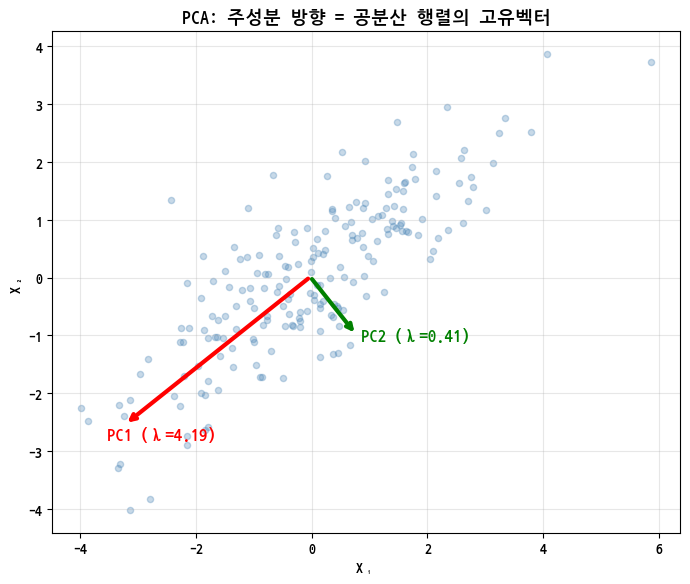

In [60]:
# PCA 간단 예제: 2차원 데이터
np.random.seed(42)
n = 200

# 상관이 있는 2차원 데이터 생성
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # 공분산 행렬
data = np.random.multivariate_normal(mean, cov, n)

# 표본 공분산 행렬
S = np.cov(data.T)
print("표본 공분산 행렬 S =")
print(np.round(S, 4))

# 고유분해
vals, vecs = LA.eigh(S)
# 내림차순 정렬
idx = np.argsort(vals)[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

print(f"고윳값: {vals}")
print(f"분산 설명 비율: {vals / vals.sum()}")
print(f"제1 주성분 방향: {vecs[:, 0]}")
print(f"제2 주성분 방향: {vecs[:, 1]}")

# 시각화
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=20, c='steelblue')

# 주성분 방향 화살표
origin = data.mean(axis=0)
for i, (val, color, label) in enumerate(zip(vals, ['red', 'green'], ['PC1', 'PC2'])):
    direction = vecs[:, i] * np.sqrt(val) * 2
    ax.annotate('', xy=origin + direction, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.text(*(origin + direction * 1.1), f'{label} (λ={val:.2f})',
            fontsize=12, color=color, fontweight='bold')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('PCA: 주성분 방향 = 공분산 행렬의 고유벡터', fontsize=13)
ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
plt.tight_layout()
plt.show()

---

## 정리

이 노트북에서 다룬 주요 NumPy 함수 요약:

| 개념 | NumPy 함수 |
|------|-----------|
| 벡터/행렬 생성 | `np.array()`, `np.eye()`, `np.zeros()`, `np.ones()` |
| 벡터 길이(노름) | `np.linalg.norm()` |
| 내적 | `np.dot()`, `@` 연산자 |
| 행렬 곱셈 | `@` 연산자, `np.dot()` |
| 전치 | `.T` 속성 |
| 역행렬 | `np.linalg.inv()` |
| 선형방정식 풀기 | `np.linalg.solve()` |
| 행렬식 | `np.linalg.det()` |
| 행렬 계수 | `np.linalg.matrix_rank()` |
| 대각합 | `np.trace()` |
| 고윳값/고유벡터 | `np.linalg.eig()`, `np.linalg.eigh()` (대칭) |
| 행렬 거듭제곱 | `np.linalg.matrix_power()` |
